# 🌉 Bridge Structural Health: ML for Infrastructure Safety — NOTEBOOK #120

**Author:** Dean Wang | Lead Data & AI Engineer

**Government:** Dept of Infrastructure, state road authorities, Infrastructure Australia, Engineers Australia

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2000, 13)


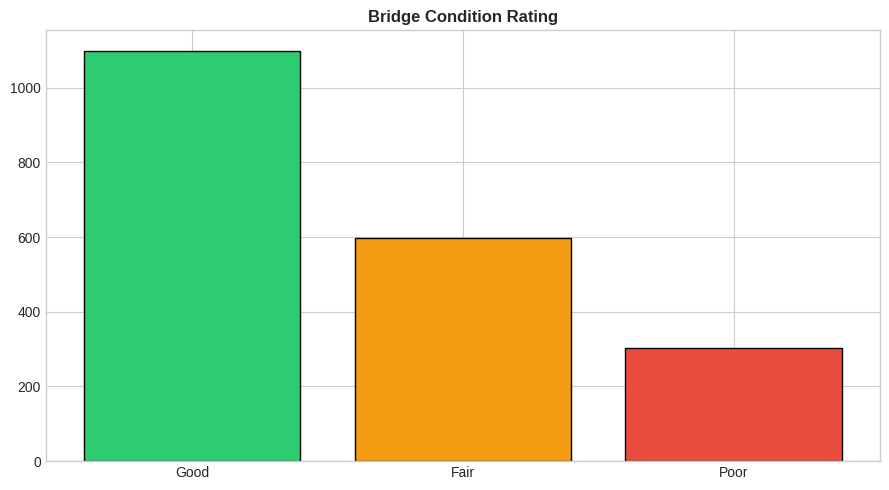

AU: 50,000+ bridges nationally. Aging infrastructure — many built 1950s-70s. $ billions in renewals.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2000,n_features=12,n_informative=9,n_classes=3,n_clusters_per_class=1,weights=[0.55,0.3,0.15],random_state=120)
names=['age_years','traffic_load','vibration_signature','corrosion_index','crack_density','deflection_mm','material_fatigue','flood_exposure','last_inspection_months','deck_condition','bearing_wear','scour_depth']
df=pd.DataFrame(X_arr,columns=names);df['condition_rating']=y;tc='condition_rating'
tl=['Good','Fair','Poor'];nc=3
print(f"Generated: {df.shape}");colors=['#2ecc71','#f39c12','#e74c3c']
fig,ax=plt.subplots(figsize=(9,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(nc),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(nc));ax.set_xticklabels(tl)
ax.set_title('Bridge Condition Rating',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: 50,000+ bridges nationally. Aging infrastructure — many built 1950s-70s. $ billions in renewals.")

LogReg: Acc=0.9520 F1=0.9514 Kappa=0.9173
RF: Acc=0.9555 F1=0.9549 Kappa=0.9226
XGB: Acc=0.9655 F1=0.9651 Kappa=0.9404
LGBM: Acc=0.9710 F1=0.9707 Kappa=0.9501
Best: LGBM


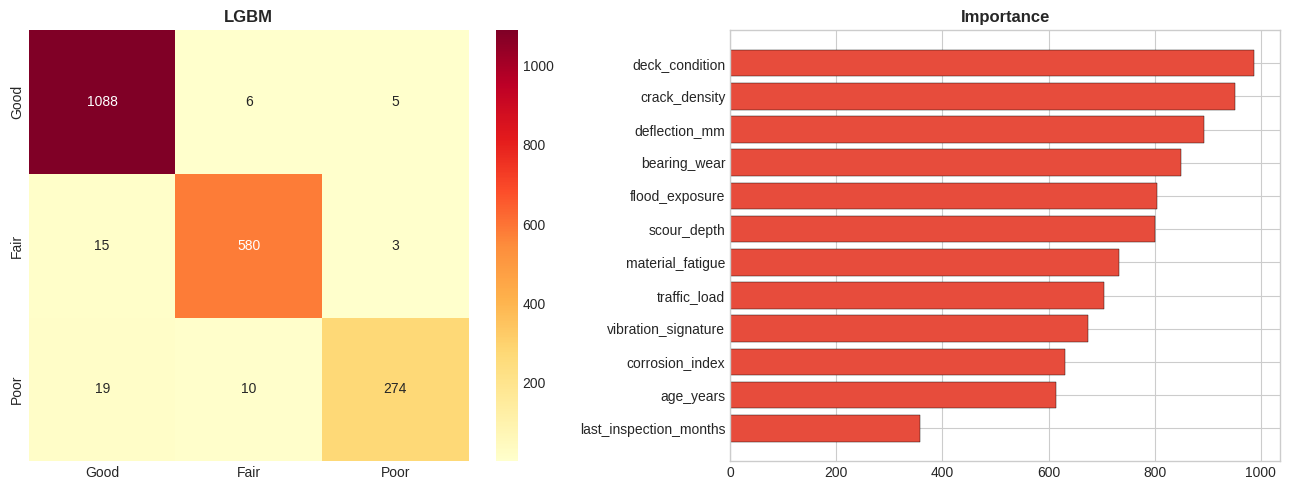

              precision    recall  f1-score   support

        Good       0.97      0.99      0.98      1099
        Fair       0.97      0.97      0.97       598
        Poor       0.97      0.90      0.94       303

    accuracy                           0.97      2000
   macro avg       0.97      0.95      0.96      2000
weighted avg       0.97      0.97      0.97      2000


#120 DEPLOYMENT: LGBM F1=0.9707 Kappa=0.9501 | IoT strain gauges -> bridge renewal prioritisation
120 NOTEBOOKS COMPLETE. kaggle.com/deanbatur | github.com/Deanmeisong


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fk=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp,average='weighted'));fk.append(cohen_kappa_score(y2[vi],yp))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} Kappa={np.mean(fk):.4f}")
best=max(results,key=lambda k:results[k]['f1']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='YlOrRd',xticklabels=tl,yticklabels=tl,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['f1']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#e74c3c',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=tl))
br=results[best];print(f"\n#120 DEPLOYMENT: {best} F1={br['f1']:.4f} Kappa={br['kappa']:.4f} | IoT strain gauges -> bridge renewal prioritisation")
print("120 NOTEBOOKS COMPLETE. kaggle.com/deanbatur | github.com/Deanmeisong")